In [2]:
using Plots
using SparseArrays
using BenchmarkTools

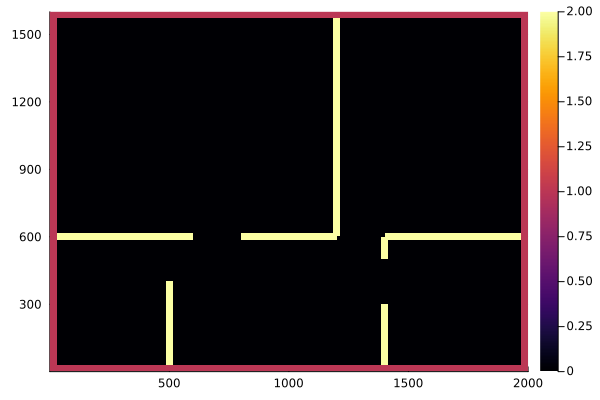

(1600, 2000)
3200000

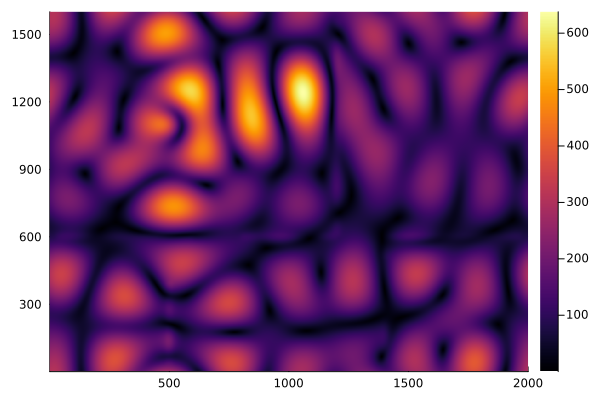

In [22]:

k(f) = (2 * π * f) / (3 * 10^8)

"""
function next_u(u_index, h, f_grid, u_grid; k = 50)
    i,j = u_index
    north = (i + 1) > 80 ? u_grid[1,j] : u_grid[i+1,j]
    south = (i - 1) < 1 ? u_grid[80,j] : u_grid[i-1,j]
    east = (j + 1) > 100 ? u_grid[i,1] : u_grid[i,j+1]
    west = (j - 1) < 1 ? u_grid[i,100] : u_grid[i,j-1]
    neighbors = (north + south + east + west)
    return (neighbors - f_grid[i,j] * h^2) / (4 - k^2 * h^2)
end
"""

function f_x_y(x_r, y_r, stepsize; A= 10^4, sigma = 0.2)
    foo(x,y) = A * exp(-(((x-x_r)^2 + (y-y_r)^2)/(2 * sigma^2)));
    return [foo(x,y) for x in 0:stepsize:8-stepsize, y in 0:stepsize:10-stepsize]
end

function inside_walls_mask()
    discretisations = Int(1/0.005)
    mask = zeros(8*discretisations,10*discretisations)

    #inner walls 
    mask[586:615, 1:600] .= 2 
    mask[586:615, 800:1199] .= 2
    mask[586:615, 1400:end-1] .= 2

    mask[1:400, 486:515] .= 2
    mask[1:300, 1386:1415] .= 2
    mask[500:599, 1386:1415] .= 2
    mask[601:end, 1186:1215] .= 2

    #edges
    mask[1:30, :] .= 1
    mask[end-29:end, :] .= 1
    mask[:, 1:30] .= 1
    mask[:, end-29:end] .= 1

    return sparse(mask)
end


function construct_matrix(u_grid, mask; k0 = 50.0, h=h)
    #using column ordering since that is julia native
    
    I = Int64[]
    J = Int64[]
    V = ComplexF64[]
    rows, cols = size(u_grid)
    N = rows * cols

    # refractive indices
    n_air  = 1.0 + 0.0im
    n_wall = 2.5 + 0.5im 
    
    for j in 1:cols 
        for i in 1:rows
            p = i + (j-1)*rows
            
            north_idx = (i - 1) == 0   ? p - 1 + rows : p - 1
            south_idx = (i + 1) > rows ? p + 1 - rows : p + 1
            west_idx = (j == 1)    ? p + (cols-1)*rows : p - rows
            east_idx = (j == cols) ? p - (cols-1)*rows : p + rows
            
            idx_list = [north_idx, south_idx, west_idx, east_idx]

            # local refractive index, then local k
            n_local = mask[i,j] == 2 ? n_wall : n_air
            k_local = n_local * k0
            
            #centre
            push!(I, p)
            push!(J, p)
            push!(V, (k_local^2*h^2 - 4))
            
            #neighbors
            for idx in idx_list
                push!(I, p)
                push!(J, idx)
                push!(V, 1.0 + 0.0im)
            end
        end
    end
    return sparse(I,J,V, N, N)
end

function build_rhs(f_grid, h)
    println(size(f_grid))
    rows, cols = size(f_grid)
    b = zeros(ComplexF64, rows*cols)
    for j in 1:cols, i in 1:rows
        p = i + (j-1)*rows
        b[p] = f_grid[i,j] * h^2
    end
    return b
end

m = inside_walls_mask()
heatmap(m)
display(current())

h= 0.005
u_grid = zeros(Int(8/h), Int(10/h))
f_field = f_x_y(5.5,2.5, h)
A = construct_matrix(u_grid, m; k0=3, h=h)
b = build_rhs(f_field, h)
u_vec = test(A,b)
print(length(u_vec))
u = reshape(u_vec, size(u_grid))

heatmap(abs.(u))


In [ ]:
@benchmark (test(A,b))

In [ ]:
@benchmark (construct_matrix(u_grid; k=19, h=h))